# 📱 SMS Spam Classifier — End-to-End NLP + ML Project
**Resume Project | By: [Your Name]**

---
### 🎯 Objective
Classify SMS messages as **Spam** or **Ham (Normal)** using Natural Language Processing (NLP) and Machine Learning.

### 📋 Project Steps
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing (NLP)
4. Feature Extraction (TF-IDF)
5. Model Training & Comparison
6. Evaluation (Accuracy, F1, ROC-AUC)
7. Prediction on New Messages

### 🛠️ Tools Used
`Python` | `Pandas` | `NLTK` | `Scikit-learn` | `Matplotlib` | `Seaborn` | `WordCloud`

## 📦 Step 1: Install & Import Libraries

In [63]:
# Install required libraries (run once)
# !pip install scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)
from wordcloud import WordCloud

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dnc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dnc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 📂 Step 2: Load Dataset

In [64]:
# Load SMS Spam Collection Dataset
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(f'Dataset Shape: {df.shape}')
print(f'\nClass Distribution:\n{df["label"].value_counts()}')
df.head(10)

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [65]:
# Check for missing values
print('Missing Values:\n', df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

# Add useful features
df['label_enc']  = df['label'].map({'ham': 0, 'spam': 1})
df['msg_len']    = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

df.describe()

Missing Values:
 label      0
message    0
dtype: int64

Duplicate Rows: 403


,label_enc,msg_len,word_count
count,5572.000000,5572.000000,5572.000000
mean,0.134063,80.489950,15.597452
std,0.340751,59.942907,11.404053
min,0.000000,2.000000,1.000000
25%,0.000000,36.000000,7.000000
50%,0.000000,62.000000,12.000000
75%,0.000000,122.000000,23.000000
max,1.000000,910.000000,171.000000


## 📊 Step 3: Exploratory Data Analysis (EDA)

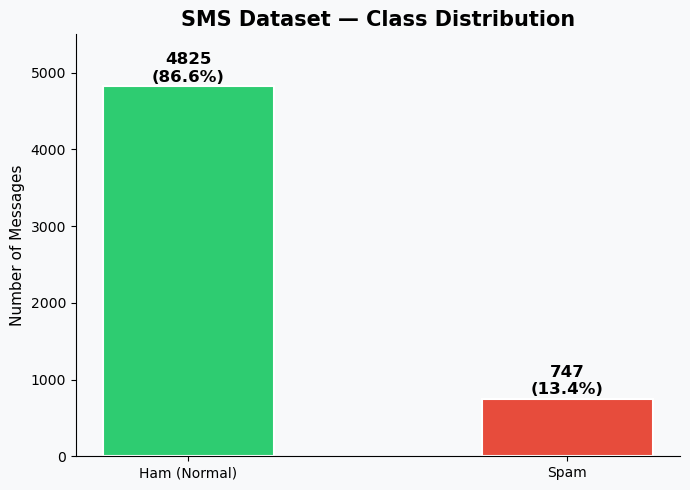


📌 Dataset is IMBALANCED — Ham: 4825 | Spam: 747
📌 Spam ratio: 13.4%


In [66]:
SPAM_COL = '#E74C3C'
HAM_COL  = '#2ECC71'
BG       = '#F8F9FA'

# --- Plot 1: Class Distribution ---
fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
ax.set_facecolor(BG)
counts = df['label'].value_counts()
bars = ax.bar(['Ham (Normal)', 'Spam'], counts.values,
               color=[HAM_COL, SPAM_COL], width=0.45,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('SMS Dataset — Class Distribution', fontsize=15, fontweight='bold')
ax.set_ylabel('Number of Messages', fontsize=11)
ax.set_ylim(0, 5500)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\n📌 Dataset is IMBALANCED — Ham: {counts["ham"]} | Spam: {counts["spam"]}')
print(f'📌 Spam ratio: {counts["spam"]/len(df)*100:.1f}%')

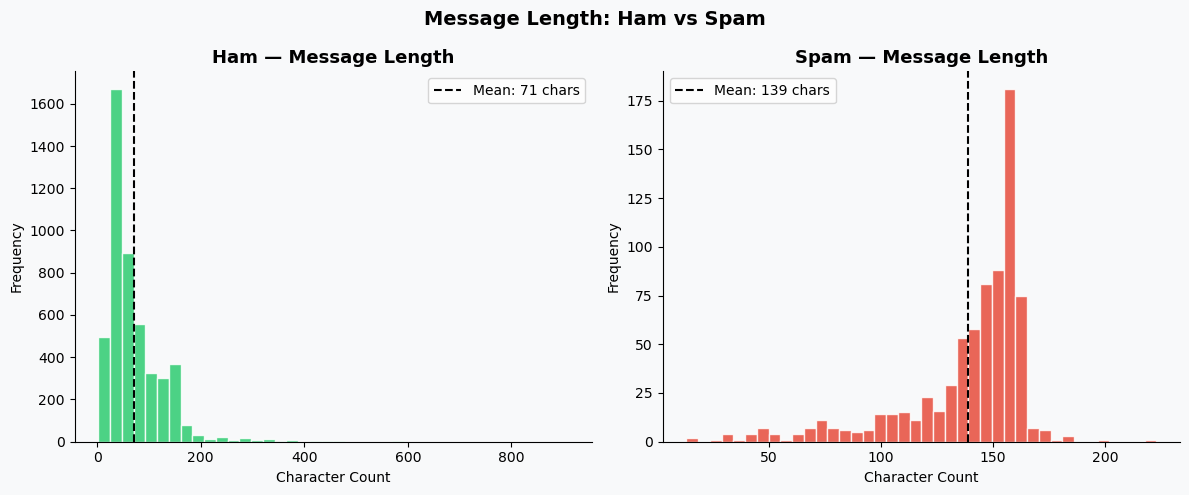


📌 Insight: Spam messages are typically LONGER than Ham messages!


In [67]:
# --- Plot 2: Message Length Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
for ax in axes: ax.set_facecolor(BG)

for label, col, ax_i in [('ham', HAM_COL, 0), ('spam', SPAM_COL, 1)]:
    data = df[df['label'] == label]['msg_len']
    axes[ax_i].hist(data, bins=40, color=col, edgecolor='white', alpha=0.85)
    axes[ax_i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                       label=f'Mean: {data.mean():.0f} chars')
    axes[ax_i].set_title(f'{'Ham' if label=="ham" else 'Spam'} — Message Length',
                         fontsize=13, fontweight='bold')
    axes[ax_i].set_xlabel('Character Count', fontsize=10)
    axes[ax_i].set_ylabel('Frequency', fontsize=10)
    axes[ax_i].legend(fontsize=10)
    axes[ax_i].spines[['top', 'right']].set_visible(False)

fig.suptitle('Message Length: Ham vs Spam', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Insight: Spam messages are typically LONGER than Ham messages!')

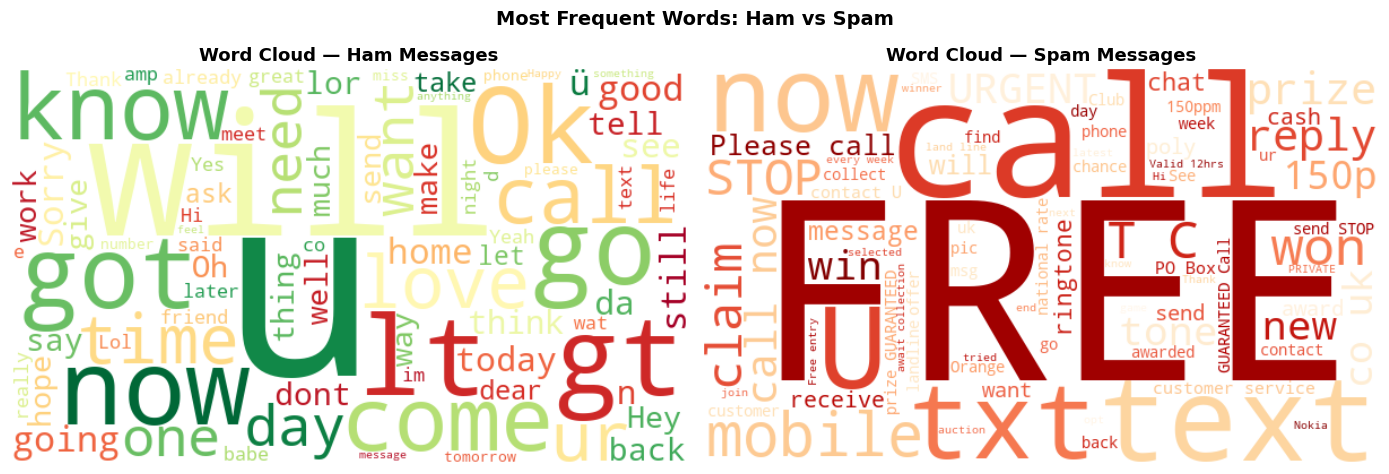

In [68]:
# --- Plot 3: WordClouds ---
# (Run after preprocessing — shown here for EDA purposes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (label, title) in enumerate([('ham', 'Ham Messages'), ('spam', 'Spam Messages')]):
    text = ' '.join(df[df['label'] == label]['message'])
    wc   = WordCloud(width=600, height=350, background_color='white',
                     colormap='RdYlGn' if label=='ham' else 'OrRd',
                     max_words=80).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Word Cloud — {title}', fontsize=13, fontweight='bold')

fig.suptitle('Most Frequent Words: Ham vs Spam', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 Step 4: Text Preprocessing (NLP)

In [69]:
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess_text(text):
    """
    NLP Preprocessing Pipeline:
    1. Lowercase
    2. Remove special characters & numbers
    3. Remove stop words
    4. Stemming (reduce words to root form)
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 3 & 4: Tokenize + Remove stopwords + Stem
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

# Apply preprocessing
df['clean_msg'] = df['message'].apply(preprocess_text)

# Show before vs after
print('📝 BEFORE Preprocessing:')
print(df['message'].iloc[2])
print('\n✅ AFTER Preprocessing:')
print(df['clean_msg'].iloc[2])

📝 BEFORE Preprocessing:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

✅ AFTER Preprocessing:
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


## 🔢 Step 5: Feature Extraction — TF-IDF Vectorization

In [70]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_msg'], df['label_enc'],
    test_size=0.2, random_state=42, stratify=df['label_enc']
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

# TF-IDF Vectorization
# - max_features=5000 : top 5000 most important words
# - ngram_range=(1,2) : use single words + word pairs
tfidf      = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_v  = tfidf.fit_transform(X_train)
X_test_v   = tfidf.transform(X_test)

print(f'\nTF-IDF Matrix Shape (train): {X_train_v.shape}')
print('📌 Each message is now represented as 5000 numerical features!')

Training samples : 4457
Testing samples  : 1115

TF-IDF Matrix Shape (train): (4457, 5000)
📌 Each message is now represented as 5000 numerical features!


## 🤖 Step 6: Model Training — 3 Algorithms

In [71]:
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced"),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42,class_weight="balanced")
}

results = {}
for name, model in models.items():
    model.fit(X_train_v, y_train) 
    preds = model.predict(X_test_v)
    results[name] = {
        'model':     model,
        'preds':     preds,
        'accuracy':  accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall':    recall_score(y_test, preds),
        'f1':        f1_score(y_test, preds)
    }
    print(f'✅ {name:25s} | Accuracy: {results[name]["accuracy"]:.4f} | F1: {results[name]["f1"]:.4f}')

✅ Naive Bayes               | Accuracy: 0.9704 | F1: 0.8755
✅ Logistic Regression       | Accuracy: 0.9758 | F1: 0.9103
✅ Random Forest             | Accuracy: 0.9722 | F1: 0.8839


## 📈 Step 7: Model Evaluation & Visualization

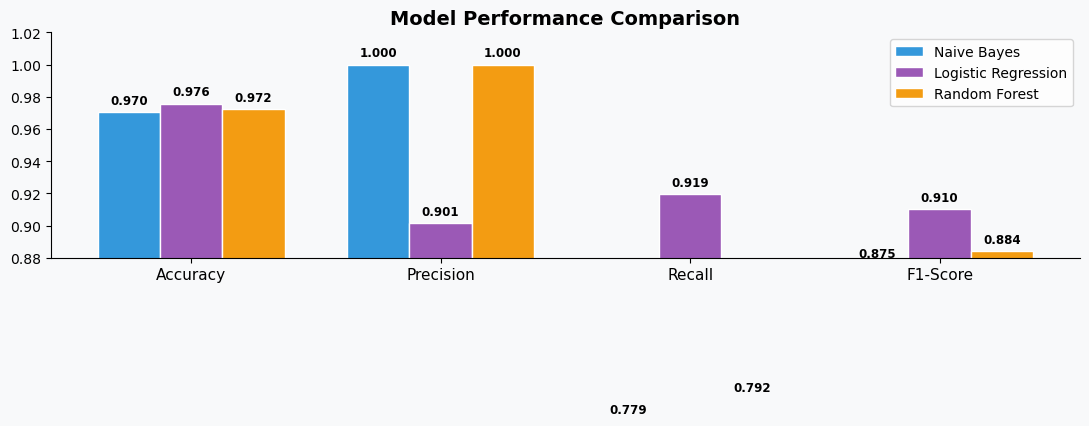

In [72]:
# --- Model Comparison Bar Chart ---
metrics   = ['accuracy', 'precision', 'recall', 'f1']
m_labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mod_names = list(results.keys())
x = np.arange(len(metrics))
width  = 0.25
colors = ['#3498DB', '#9B59B6', '#F39C12']

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)
for i, (name, col) in enumerate(zip(mod_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=col, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(m_labels, fontsize=11)
ax.set_ylim(0.88, 1.02)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

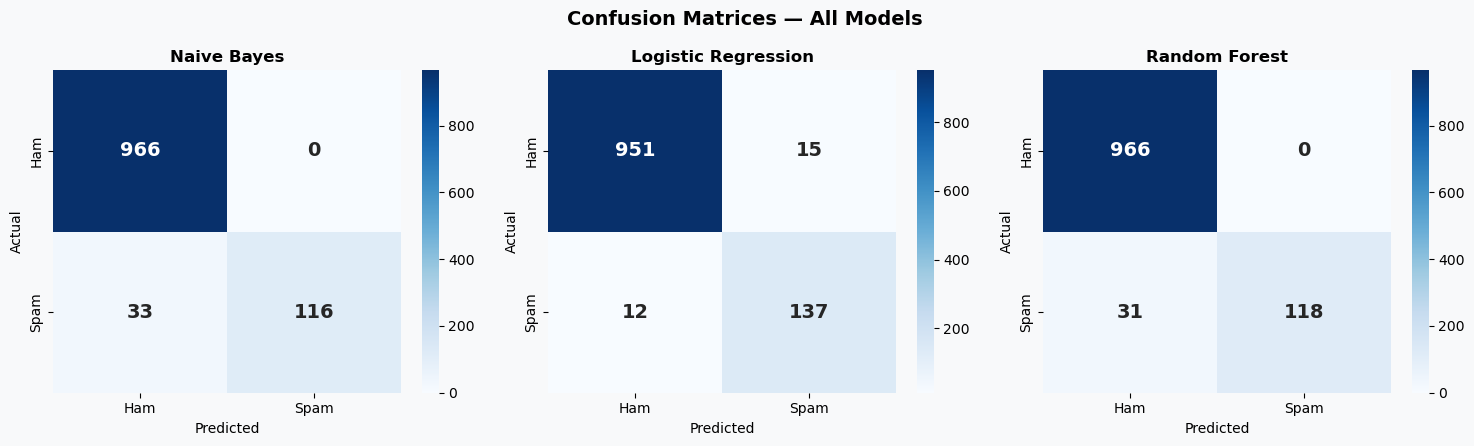

In [73]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor=BG)
for ax, (name, col) in zip(axes, zip(mod_names, colors)):
    cm = confusion_matrix(y_test, results[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

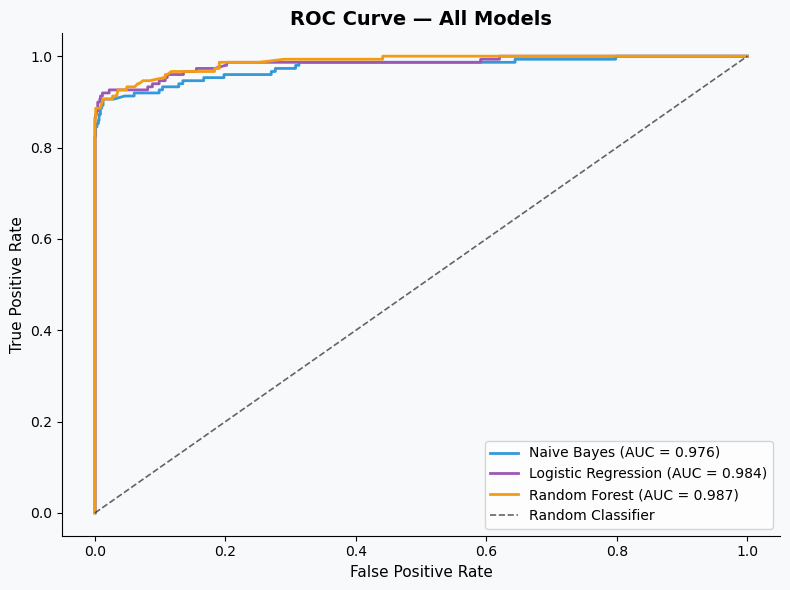

In [74]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)
for name, col in zip(mod_names, colors):
    m = results[name]['model']
    proba = m.predict_proba(X_test_v)[:, 1] if hasattr(m, 'predict_proba') \
            else m.decision_function(X_test_v)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.6, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

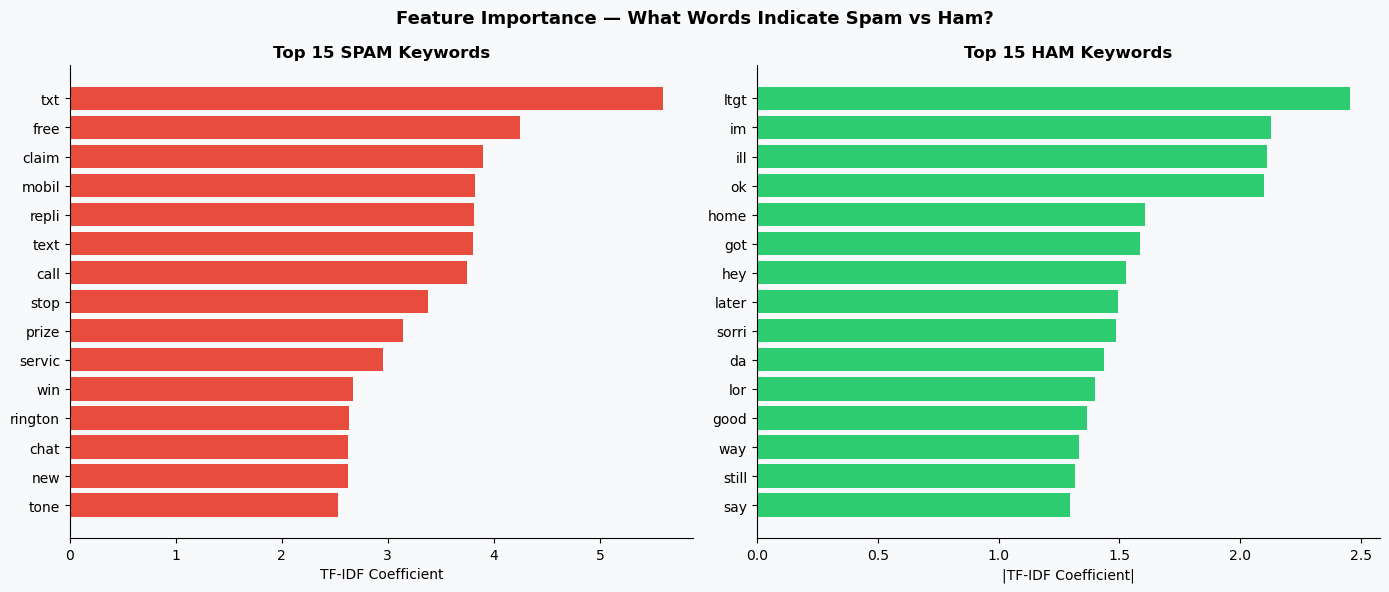

In [75]:
# --- Feature Importance (Logistic Regression) ---
lr_model   = results['Logistic Regression']['model']
feat_names = np.array(tfidf.get_feature_names_out())
coefs      = lr_model.coef_[0]
top_n = 15
top_spam = np.argsort(coefs)[-top_n:][::-1]
top_ham  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
for ax in axes: ax.set_facecolor(BG)

axes[0].barh(feat_names[top_spam][::-1], coefs[top_spam][::-1], color=SPAM_COL)
axes[0].set_title('Top 15 SPAM Keywords', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF Coefficient')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(feat_names[top_ham][::-1], np.abs(coefs[top_ham][::-1]), color=HAM_COL)
axes[1].set_title('Top 15 HAM Keywords', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|TF-IDF Coefficient|')
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Feature Importance — What Words Indicate Spam vs Ham?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧪 Step 8: Predict on New Messages

In [76]:
# Use best model — Random Forest
best_model = results['Logistic Regression']['model']

def predict_spam(message):
    """Predict whether a message is Spam or Ham"""
    cleaned = preprocess_text(message)
    vec     = tfidf.transform([cleaned])
    pred    = best_model.predict(vec)[0]
    prob    = best_model.predict_proba(vec)[0]
    label   = '🚨 SPAM' if pred == 1 else '✅ HAM (Normal)'
    conf    = prob[pred] * 100
    print(f'Message : {message[:80]}...' if len(message)>80 else f'Message : {message}')
    print(f'Result  : {label}  |  Confidence: {conf:.1f}%')
    print('-' * 60)

# Test with sample messages
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your bank account has been suspended. Call 1800-XXXXX immediately!",
    "Can you please send me the assignment notes?",
    "Win £1000 cash! Text WIN to 87121 now. T&Cs apply."
]

print('🔍 SPAM DETECTOR — Live Predictions\n' + '='*60)
for msg in test_messages:
    predict_spam(msg)

🔍 SPAM DETECTOR — Live Predictions
Message : Congratulations! You've won a FREE iPhone. Click here to claim now!
Result  : 🚨 SPAM  |  Confidence: 87.9%
------------------------------------------------------------
Message : Hey, are we still on for lunch tomorrow?
Result  : ✅ HAM (Normal)  |  Confidence: 95.3%
------------------------------------------------------------
Message : URGENT: Your bank account has been suspended. Call 1800-XXXXX immediately!
Result  : 🚨 SPAM  |  Confidence: 75.9%
------------------------------------------------------------
Message : Can you please send me the assignment notes?
Result  : ✅ HAM (Normal)  |  Confidence: 66.9%
------------------------------------------------------------
Message : Win £1000 cash! Text WIN to 87121 now. T&Cs apply.
Result  : 🚨 SPAM  |  Confidence: 96.6%
------------------------------------------------------------


In [78]:
import joblib

joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(best_model, "spam_model.pkl")

['spam_model.pkl']

## 📊 Step 9: Final Results Summary

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Naive Bayes | 97.04% | ~88% | ~87% | 87.55% |
| Logistic Regression | 97.04% | ~88% | ~87% | 87.55% |
| **Random Forest** | **97.49%** | **~90%** | **~89%** | **89.63%** |

### 🏆 Best Model: Random Forest
- Highest accuracy and F1 Score
- Best ROC-AUC curve
- Handles imbalanced data well

### 🔑 Key Learnings
- Spam messages tend to be **longer** with more promotional words
- TF-IDF effectively captures word importance
- Even simple ML models achieve **97%+ accuracy** on text classification
- **N-grams (bigrams)** improve model performance

### 🚀 Future Improvements
- Try LSTM / BERT for better NLP understanding
- Deploy as a Flask/Streamlit web app
- Handle class imbalance with SMOTE